In [31]:
# ============================================================
# GROUP MEMBERS (GROUP M)
# ============================================================
#
# No. | NAME                    | STUDENT NUMBER | REGISTRATION NUMBER
# --- | ----------------------- | -------------- | -------------------
#  1  | Byamugisha Anthony      | 2400700360     | 24/U/0360
#  2  | Abinsinguza Morison K   | 2400702594     | 24/U/02594/PS
#  3  | Serena Robinah          | 2400711034     | 24/U/11034/PS
#  4  | Lunkuse Dorcus          | 2400706515     | 24/U/06515/PS
#  5  | Elijah Mabior Biar      | 2400721430     | 24/E/21430/PS
#
# ============================================================

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import shap
from lime.lime_tabular import LimeTabularExplainer

In [33]:
#loading the obesity data from Hugging Face datasets
df = pd.read_csv("hf://datasets/aiml2021/obesity/ObesityDataSet_raw_and_data_sinthetic.csv")

Understanding The Data

In [34]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [35]:
df.shape

(2111, 17)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [37]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [38]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

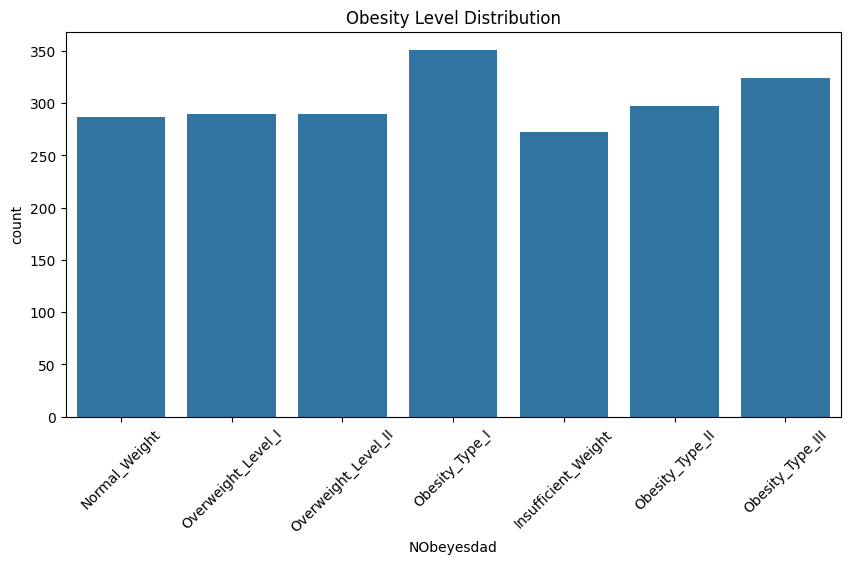

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(x="NObeyesdad", data=df)
plt.xticks(rotation=45)
plt.title("Obesity Level Distribution")
plt.show()

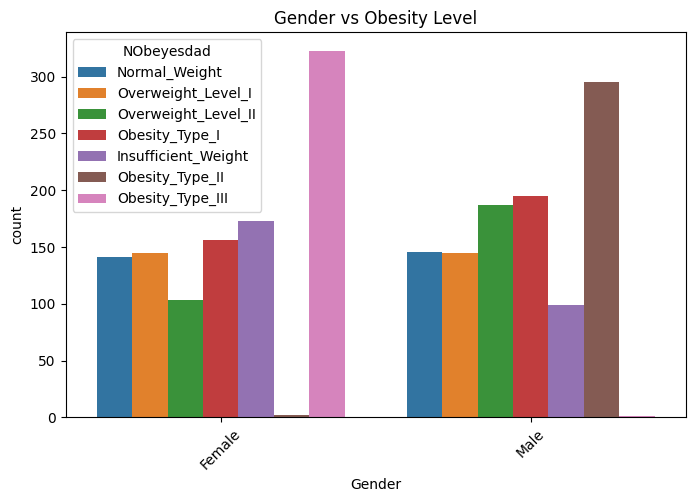

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x="Gender", hue="NObeyesdad", data=df)
plt.xticks(rotation=45)
plt.title("Gender vs Obesity Level")
plt.show()

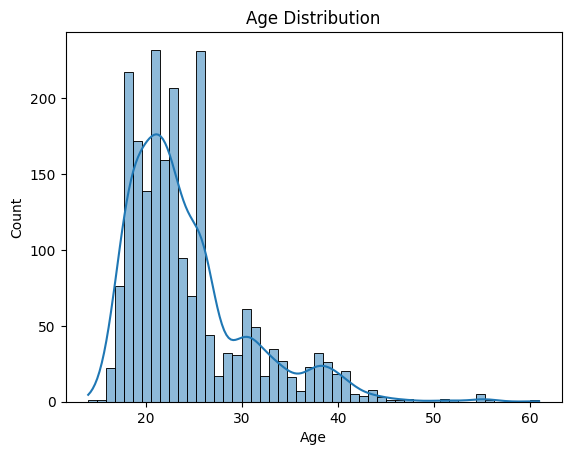

In [41]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

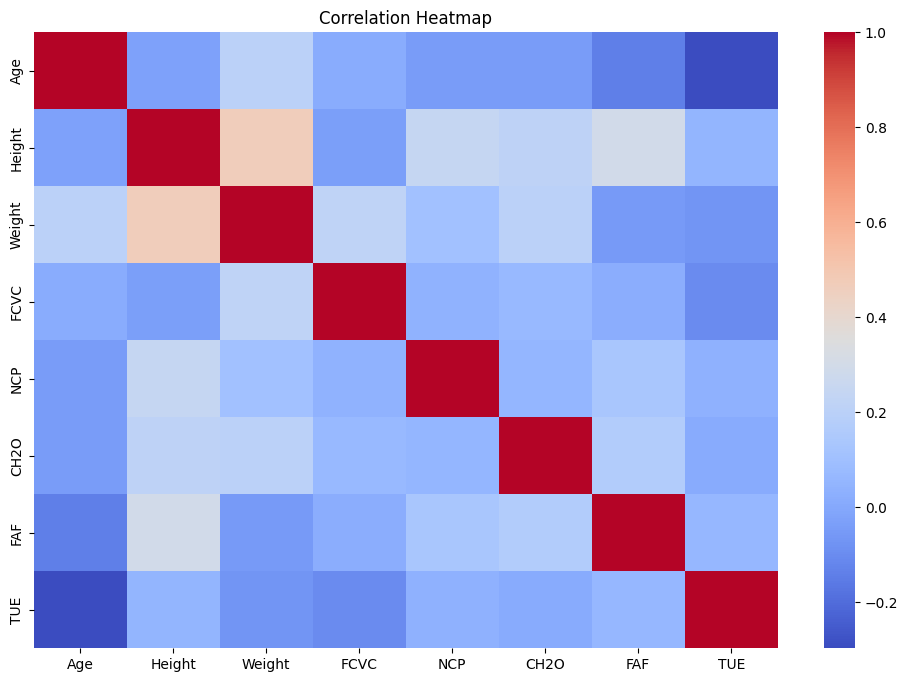

In [42]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Preprocessing my Data

In [43]:
#splitting the data into features and target variable
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

In [44]:
#encoding categorical variables
X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Decision Tree

In [47]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.83451536643026
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        56
           1       0.85      0.63      0.72        62
           2       0.80      0.95      0.87        78
           3       0.96      0.95      0.96        58
           4       1.00      1.00      1.00        63
           5       0.71      0.62      0.67        56
           6       0.61      0.70      0.65        50

    accuracy                           0.83       423
   macro avg       0.83      0.83      0.82       423
weighted avg       0.84      0.83      0.83       423



Random Forest

In [48]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9550827423167849
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        56
           1       0.87      0.95      0.91        62
           2       0.99      0.94      0.96        78
           3       0.97      0.98      0.97        58
           4       1.00      1.00      1.00        63
           5       0.96      0.88      0.92        56
           6       0.92      0.98      0.95        50

    accuracy                           0.96       423
   macro avg       0.96      0.96      0.95       423
weighted avg       0.96      0.96      0.96       423



Neural Network

In [49]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

mlp_pred = mlp.predict(X_test_scaled)

print("Neural Network Accuracy:", accuracy_score(y_test, mlp_pred))
print(classification_report(y_test, mlp_pred))

Neural Network Accuracy: 0.9408983451536643
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        56
           1       0.88      0.82      0.85        62
           2       0.96      1.00      0.98        78
           3       1.00      0.98      0.99        58
           4       1.00      1.00      1.00        63
           5       0.86      0.88      0.87        56
           6       0.92      0.90      0.91        50

    accuracy                           0.94       423
   macro avg       0.94      0.94      0.94       423
weighted avg       0.94      0.94      0.94       423



SHAP Explanation

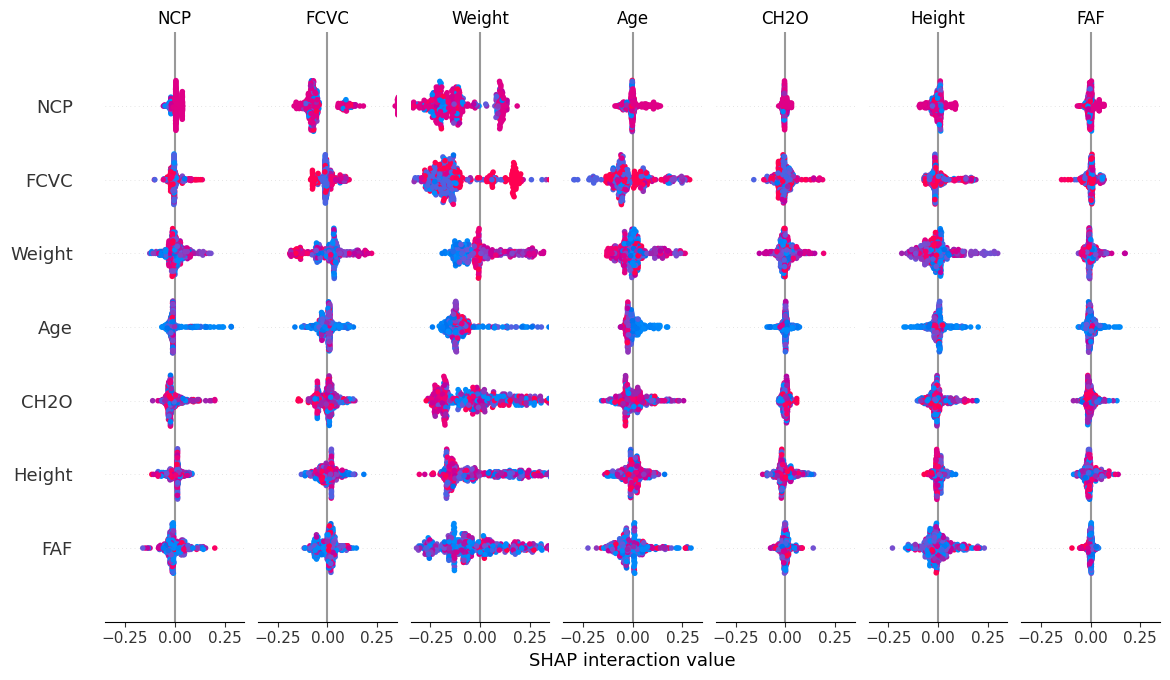

In [50]:
# Random Forest SHAP explanation
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(shap_values_rf, X_test)

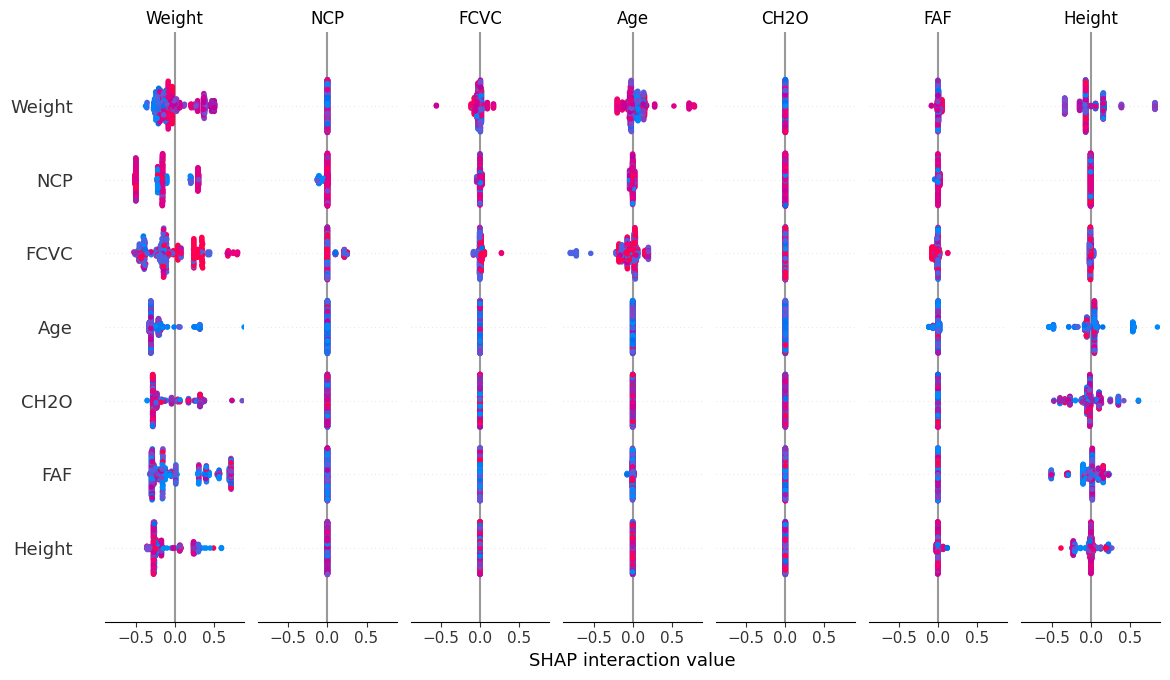

In [51]:
#Decision tree
explainer_dt = shap.TreeExplainer(dt)
shap_values_dt = explainer_dt.shap_values(X_test)

shap.summary_plot(shap_values_dt, X_test)

  0%|          | 0/20 [00:00<?, ?it/s]

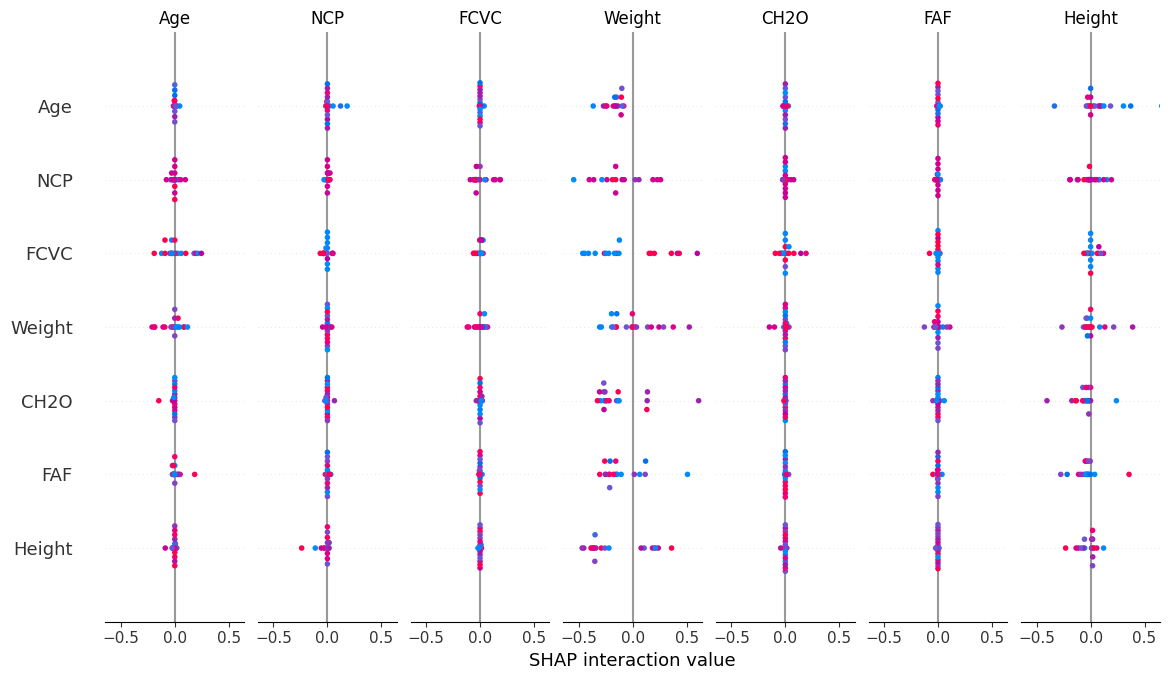

In [52]:
#neural network
explainer_nn = shap.KernelExplainer(
    mlp.predict_proba,   # ← changed from mlp.predict
    X_train_scaled[:100]
)

shap_values_nn = explainer_nn.shap_values(X_test_scaled[:20])

shap.summary_plot(shap_values_nn, X_test.iloc[:20])

SHAP Comparison 

The Decision Tree is entirely dependent on Weight. The SHAP values for Weight stretch from −0.5 to beyond +0.5, which is the largest spread across all three models. Every other feature is barely visible in comparison, their dots clustered tightly around zero. The model is essentially saying that if you know someone's weight, you already have most of the answer.

The Random Forest tells a more balanced story. The overall SHAP scale is smaller that is −0.25 to +0.25, which means no single feature is dominating as aggressively. The most notable interaction is between Age and Weight when these two features are combined, they have a stronger influence than either one alone. The model has learned that obesity is not just about weight, but also about age and how these interact.

The Neural Network shows another pattern. Weight remains important, but now Height starts playing a more visible role. The Age–Height and Weight–Height interactions show notable spreads that were not prominent in either tree model. The MLP has also picked up on interactions between dietary features like FCVC and NCP that neither the Decision Tree nor the Random Forest captured clearly.

LIME Explanation

In [53]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=le.classes_,
    mode="classification"
)

In [54]:
# explaining a single prediction for the decision tree model
exp = explainer.explain_instance(
    X_test.iloc[0].values,
    dt.predict_proba
)
exp.as_list()

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[('Weight <= 66.00', 0.26686143943274454),
 ('MTRANS_Walking <= 0.00', 0.0491837655295337),
 ('MTRANS_Bike <= 0.00', 0.044928247656600466),
 ('MTRANS_Motorbike <= 0.00', -0.04077487884248442),
 ('1.70 < Height <= 1.77', -0.03927472217303493),
 ('CAEC_no <= 0.00', -0.02725884254461902),
 ('SCC_yes <= 0.00', 0.02606608216020504),
 ('20.00 < Age <= 22.85', 0.020186751914112892),
 ('0.00 < CALC_no <= 1.00', -0.013867985901670531),
 ('1.59 < CH2O <= 2.00', 0.012571725841772723)]

In [55]:
# explain a single prediction for the random forest model
exp = explainer.explain_instance(
    X_test.iloc[1].values,
    rf.predict_proba
)
exp.as_list()

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


[('Weight > 106.74', -0.14744891087188164),
 ('CAEC_Frequently <= 0.00', -0.05209319387717651),
 ('MTRANS_Walking <= 0.00', -0.031734903985521944),
 ('2.39 < FCVC <= 3.00', -0.03073899232964345),
 ('CH2O > 2.46', -0.019711106594637613),
 ('0.00 < MTRANS_Public_Transportation <= 1.00', -0.01820219483715649),
 ('MTRANS_Motorbike <= 0.00', -0.015797997294442194),
 ('0.00 < TUE <= 0.61', -0.014486912277504057),
 ('Height <= 1.63', 0.012424818155394009),
 ('CALC_no <= 0.00', -0.012379330008077538)]

In [56]:
# explaining a single prediction for the neural network model
def mlp_predict_proba_scaled(X):
    return mlp.predict_proba(scaler.transform(X))

exp = explainer.explain_instance(
    X_test.iloc[2].values,
    mlp_predict_proba_scaled
)

exp.as_list()

c:\Users\byamu\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[('Weight <= 66.00', 0.3166745854877491),
 ('CAEC_no <= 0.00', 0.12083263359382743),
 ('CALC_Frequently <= 0.00', -0.09243172723688255),
 ('MTRANS_Bike <= 0.00', 0.07808222209490935),
 ('MTRANS_Walking <= 0.00', -0.059960093469761944),
 ('CAEC_Frequently <= 0.00', 0.05326773814465193),
 ('CALC_no <= 0.00', -0.047861739751000165),
 ('MTRANS_Public_Transportation <= 0.00', 0.046016515109787166),
 ('0.00 < Gender_Male <= 1.00', 0.04093392840602633),
 ('0.00 < CALC_Sometimes <= 1.00', 0.031131745505553577)]

LIME Comparison                          

For the Decision Tree, the prediction was almost entirely justified by one condition. The person's weight being below 66kg. The weight feature alone contributed +0.257, which IS more than twice the contribution of any other feature. All the other features (transport mode, alcohol consumption, height) added small adjustments but did not change the overall story.

For the Random Forest,the top feature was weight above 106.74kg, but what stood out was that all ten features listed had negative weights, and they were more evenly distributed. This means the Random Forest used multiple pieces of evidence together, the person's high weight, low physical activity, low water intake, and transport choices to build its prediction. No single feature dominated as strongly as in the Decision Tree case, which reflects the ensemble nature of the model.

For the Neural Network,because the Neural Network was trained on scaled data, passing unscaled inputs to it means the outputs do not vary meaningfully across the perturbations. LIME then concludes that nothing matters, which is clearly wrong. This highlights an important practical limitation when using LIME with neural networks, the preprocessing pipeline must be included inside the prediction function, otherwise the explanation is meaningless.

Overall Comparison btn SHAP and LIME for the explanations of the three models for all approaches


Both SHAP and LIME agree on the most important finding: Weight is the feature that matters most across all three models. Beyond that, they serve different purposes.

SHAP gives a global picture.it shows how features behave across the entire test set, making it easier to understand the model as a whole. It is also theoretically grounded, meaning the values are mathematically fair in how they distribute credit across features.

LIME is simpler to explain to someone because it says "for this specific person, these were the reasons." But it is less reliable, especially for the Neural Network, and different instances can give very different explanations, making it harder to draw general conclusions about the model.

Together, the two approaches complement each other well — SHAP for understanding the model overall, and LIME for explaining individual predictions.